## Dataset Analysis — Black-Box Modelling of Multiband Saturation

In this notebook, we perform an data analysis of the dataset provided for the project. We examine the distribution of the data and the clean and saturated (target) signals.

The outputs of this notebook are saved in the SAVE_DIR directory, which is defined in the configuration cell.

In [1]:
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
import scipy.signal
import os
import librosa
import numpy as np
import librosa.display
from pathlib import Path
import IPython.display as ipd
import matplotlib.pyplot as plt
from IPython.display import Audio

print(torch.__version__)
print(torchaudio.__version__)

2.11.0+cpu
2.11.0+cpu


### Configuration

In [ ]:
CLEAN_DIR = r"Path\to\your\diretory\Dataset\clean"
SAT_DIR   = r"Path\to\your\diretory\Dataset\saturated"
SAVE_DIR  = "analysis_outputs_multiband"
SR        = 44100
CHUNK     = 8192

# Create the output directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

### Dataset Overview

In [3]:
clean_files = sorted(Path(CLEAN_DIR).rglob("*.wav"))
saturated_files = sorted(Path(SAT_DIR).rglob("*.wav"))

durations, pair_files, missing, ignored_files, ig_name = [], [], [], [], []

for cf in clean_files:
    sf = Path(SAT_DIR).rglob(cf.stem + "_saturated.wav")  # saturated samples have the same name with "_saturated" suffix
    sf = list(sf)
    if not sf:
        missing.append(cf.name)
        continue
    sf = sf[0]
    pair_files.append((cf, sf))

    y_c, sr_clean = torchaudio.load(str(cf))        
    y_s, sr_sat = torchaudio.load(str(sf))

    duration = y_c.shape[-1] / sr_clean
    
    if duration < 6:
        durations.append(duration)
    else:
        ignored_files.append(duration)
        ig_name.append(cf.name)
        

durations = np.array(durations)
total_duration = durations.sum()/60
total_samples = (durations * sr_clean).astype(int).sum()

if sr_clean != sr_sat:
    raise ValueError(f"Sample rates diferentes: clean={sr_clean}, sat={sr_sat}")
else:
    print(f"Sample rate: {sr_clean} Hz")

print(f"Total clean files found:     {len(clean_files)}")
print(f"Total saturated files found: {len(saturated_files)}")
print(f"Ignored Files (>6s): {len(ignored_files)}")
print(f"Valid Pairs    : {len(durations)}")
print(f"Missing Pairs  : {len(missing)}")
print(f"Total Duration : {total_duration:.1f} min")
print(f"Mean Duration  : {durations.mean():.3f} s  (min={durations.min():.3f}, max={durations.max():.3f})")

print("\nFiles ignored due to duration > 6s:")
for name in ig_name:
    print(f"  - {name}")

Sample rate: 44100 Hz
Total clean files found:     1873
Total saturated files found: 1873
Ignored Files (>6s): 1
Valid Pairs    : 1872
Missing Pairs  : 0
Total Duration : 85.8 min
Mean Duration  : 2.750 s  (min=1.564, max=5.264)

Files ignored due to duration > 6s:
  - BS_3_EQ_3_MU_NO_4_12.wav


### Clean/Saturated Audio Signal Preview

In [4]:
clean_file_preview = Path(CLEAN_DIR) / "FS" / "BS_1_EQ_1_FS_NO_1_0.wav"
clean_waveform, sr_clean = torchaudio.load(clean_file_preview)

saturated_file_preview = Path(SAT_DIR) / "FS" / "BS_1_EQ_1_FS_NO_1_0_saturated.wav"
sat_waveform, sr_sat = torchaudio.load(saturated_file_preview)

In [5]:
# clean audio signal preview
Audio(clean_waveform.numpy(), rate=sr_clean)

In [6]:
# saturated audio signal preview
Audio(sat_waveform.numpy(), rate=sr_sat)

### Waveform and Spectrogram Comparison **(Using PyTorch Audio)**

This code is based on the tutorial from PyTorch Audio: https://docs.pytorch.org/audio/stable/tutorials/audio_feature_extractions_tutorial.html

In [7]:
def plot_waveform(waveform, sr, title="Waveform", ax=None, color="steelblue"):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr

    if ax is None:
        _, ax = plt.subplots(num_channels, 1)
    ax.plot(time_axis, waveform[0], linewidth=1, color=color)
    ax.grid(False)
    ax.set_xlim([0, time_axis[-1]])
    ax.set_title(title)

def plot_spectrogram(ax, waveform, sr, title):
    spectrogram = T.Spectrogram(
        n_fft=2048,
        hop_length=512,
        power=None,
        center=True,
        pad_mode="reflect",
    )

    spec_complex = spectrogram(waveform)
    mag = spec_complex.abs()
    db = T.AmplitudeToDB(stype="magnitude", top_db=80)(mag)

    # Log frequency axis for better audio readability
    img = librosa.display.specshow(
        db[0].cpu().numpy(),
        sr=sr,
        hop_length=512,
        x_axis="time",
        y_axis="log",
        ax=ax,
        cmap="viridis"
    )
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    return img

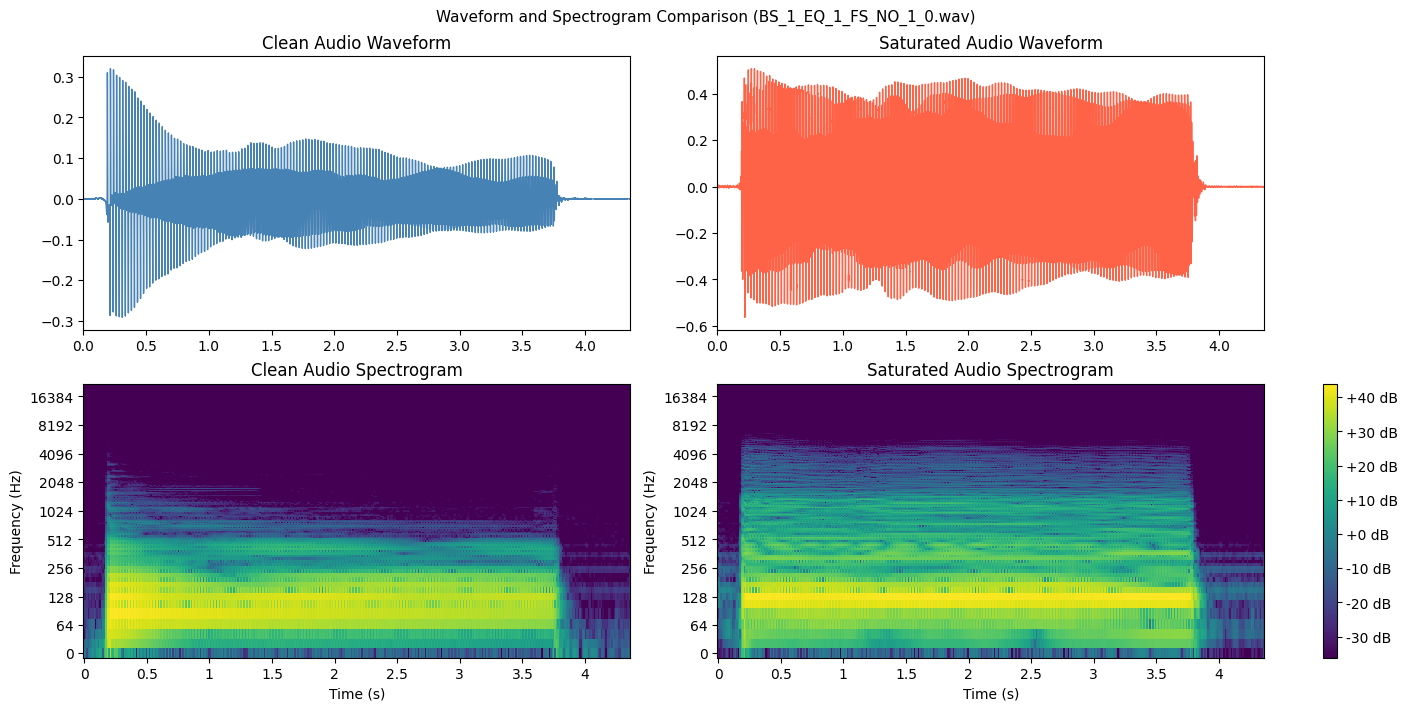

In [8]:
# 2x2 layout: waveforms on top, spectrograms on bottom
fig, axs = plt.subplots(2, 2, figsize=(14, 7), constrained_layout=True)

plot_waveform(clean_waveform, sr_clean, title="Clean Audio Waveform", ax=axs[0, 0])
plot_waveform(sat_waveform, sr_sat, title="Saturated Audio Waveform", ax=axs[0, 1], color="tomato")

plot_spectrogram(axs[1, 0], clean_waveform, sr_clean, "Clean Audio Spectrogram")
img = plot_spectrogram(axs[1, 1], sat_waveform, sr_sat, "Saturated Audio Spectrogram")

fig.colorbar(img, ax=[axs[1, 0], axs[1, 1]], format="%+2.0f dB")
fig.suptitle(f"Waveform and Spectrogram Comparison ({clean_file_preview.name})", fontsize=11)
plt.savefig(f"{SAVE_DIR}/fig4_PyTorch_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Spectrum Comparison

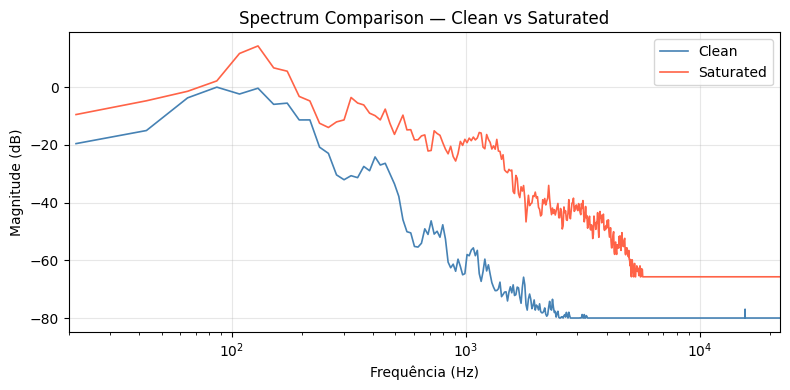

In [9]:
freqs = librosa.fft_frequencies(sr=SR, n_fft=2048)

sample_clean, _ = librosa.load(clean_file_preview, sr=SR, mono=True)
sample_saturated, _ = librosa.load(saturated_file_preview, sr=SR, mono=True)

mag_clean = np.abs(librosa.stft(sample_clean, n_fft=2048)).mean(axis=1)
mag_sat   = np.abs(librosa.stft(sample_saturated, n_fft=2048)).mean(axis=1)

ref_val = mag_clean.max()
clean_db = librosa.amplitude_to_db(mag_clean, ref=ref_val)
sat_db   = librosa.amplitude_to_db(mag_sat,   ref=ref_val)

plt.figure(figsize=(8, 4))
plt.semilogx(freqs[1:], clean_db[1:], color="steelblue", label="Clean", linewidth=1.2)
plt.semilogx(freqs[1:], sat_db[1:],   color="tomato",    label="Saturated", linewidth=1.2)
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spectrum Comparison — Clean vs Saturated")
plt.xlim(20, SR / 2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig3_spectrum_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Latency and Clipping Check

In [10]:
def estimate_latency_samples(clean_mono: np.ndarray, sat_mono: np.ndarray, sr: int, window_seconds: float = 1.0) -> int:
    """Estimate latency using cross-correlation on the highest-energy window."""
    if clean_mono.size == 0 or sat_mono.size == 0:
        return 0

    window_len = int(sr * window_seconds)
    window_len = max(256, min(window_len, clean_mono.size, sat_mono.size))
    if window_len <= 0:
        return 0

    # Find the highest-energy window in the clean signal to avoid silence bias
    energy = np.convolve(clean_mono[:].astype(np.float64) ** 2, np.ones(window_len, dtype=np.float64), mode="valid")
    start_idx = int(np.argmax(energy)) if energy.size > 0 else 0

    clean_seg = clean_mono[start_idx:start_idx + window_len]
    sat_seg = sat_mono[start_idx:start_idx + window_len]

    if clean_seg.size == 0 or sat_seg.size == 0:
        return 0

    correlation = scipy.signal.correlate(sat_seg, clean_seg, mode="full")
    lags = scipy.signal.correlation_lags(len(sat_seg), len(clean_seg), mode="full")
    return int(lags[int(np.argmax(correlation))])

In [11]:
clean_sig = clean_waveform.squeeze().numpy()
sat_sig = sat_waveform.squeeze().numpy()

latency_samples = estimate_latency_samples(clean_sig, sat_sig, sr_clean)
print(f"Estimated Latency: {latency_samples} samples ({(latency_samples / sr_clean) * 1000:.2f} ms)\n")


clean_peak = np.max(np.abs(clean_sig))
sat_peak = np.max(np.abs(sat_sig))
clean_rms = np.sqrt(np.mean(clean_sig**2))
sat_rms = np.sqrt(np.mean(sat_sig**2))

print(f"Maximum Amplitude : Clean = {clean_peak:.4f} | Sat = {sat_peak:.4f}")
print(f"Average Energy (RMS)      : Clean = {clean_rms:.4f} | Sat = {sat_rms:.4f}")

gain_factor = sat_rms / (clean_rms + 1e-8)
print(f"Average Gain Factor     : The Saturn 2 increased the RMS volume by approximately {gain_factor:.2f}x\n")

if sat_peak >= 0.99:
    print("The saturated file is in 'clipping' (reached the limit of 1.0). Try reducing the output of the VST.")
else:
    print("Signals are in a digital safe space (Below 1.0). The VST did not introduce accidental hard-clipping.")

Estimated Latency: 292 samples (6.62 ms)

Maximum Amplitude : Clean = 0.3197 | Sat = 0.5634
Average Energy (RMS)      : Clean = 0.0576 | Sat = 0.2124
Average Gain Factor     : The Saturn 2 increased the RMS volume by approximately 3.69x

Signals are in a digital safe space (Below 1.0). The VST did not introduce accidental hard-clipping.
